In [103]:
import math
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from wandb.apis.public.runs import Run

import wandb

In [104]:
api = wandb.Api()

In [105]:
runs = api.runs("graphcore/llama-mobile", filters={"config.name": "lr-sweep-v2"})

In [106]:
def cleanup_run(run: Run) -> dict[str, Any]:
    d = {}

    d["batch_size"] = run.config["training"]["batch_size"]
    d["n_steps"] = run.config["training"]["n_steps"]
    d["beta1"] = run.config["training"]["optimiser"]["betas"][0]
    d["beta2"] = run.config["training"]["optimiser"]["betas"][1]
    d["weight_decay"] = run.config["training"]["optimiser"]["weight_decay"]
    d["n_warmup_steps"] = run.config["training"]["lr_schedule"]["n_warmup_steps"]
    d["lr_exponent"] = math.log2(run.config["training"]["optimiser"]["lr"])

    history = run.history()
    d["train_loss"] = np.mean(history["train/loss"].tail(10).values)
    d["val_loss"] = run.summary["val/loss"]
    d["step_time"] = np.mean(history["perf/step_time"].values)

    return d

In [107]:
df = pd.DataFrame([cleanup_run(run) for run in runs])
df.sort_values(by="val_loss", ascending=True, inplace=True)

In [108]:
# NOTE: 2**-13 learning rate explodes, so exclude
df

,batch_size,n_steps,beta1,beta2,weight_decay,n_warmup_steps,lr_exponent,train_loss,val_loss,step_time
3,64,256,0.9,0.999,0,0,-16.0,0.042481,0.044457,25.512008
2,64,256,0.9,0.999,0,0,-17.0,0.046806,0.048667,25.242926
4,64,256,0.9,0.999,0,0,-15.0,0.047072,0.051875,25.470303
1,64,256,0.9,0.999,0,0,-18.0,0.050984,0.052764,25.553852
0,64,256,0.9,0.999,0,0,-19.0,0.059806,0.061473,26.096932
5,64,256,0.9,0.999,0,0,-14.0,0.060214,0.063550,25.425685
6,64,256,0.9,0.999,0,0,-13.0,4.828126,4.948041,25.340281


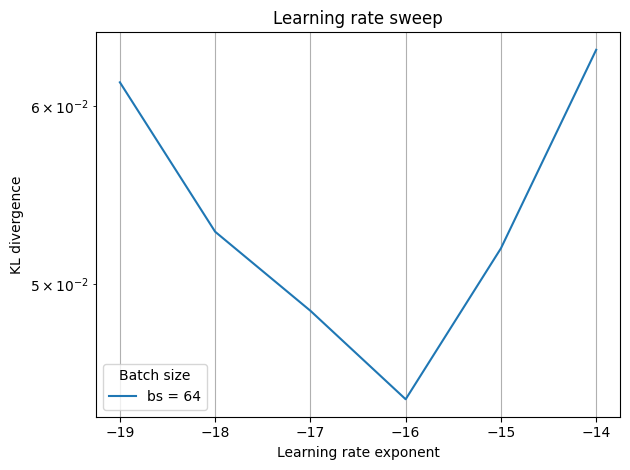

In [109]:
for bs, group in df[df["val_loss"] < 1].groupby("batch_size"):
    group_sorted = group.sort_values('lr_exponent')
    plt.plot(group_sorted["lr_exponent"], group_sorted["val_loss"], label=f"bs = {bs}")
    plt.yscale("log")
    
plt.title("Learning rate sweep")
plt.xlabel("Learning rate exponent")
plt.ylabel("KL divergence")
plt.legend(title="Batch size")
plt.grid(True)
plt.tight_layout()

In [110]:
baseline = df[df["lr_exponent"] == -16]

In [111]:
baseline

,batch_size,n_steps,beta1,beta2,weight_decay,n_warmup_steps,lr_exponent,train_loss,val_loss,step_time
3,64,256,0.9,0.999,0,0,-16.0,0.042481,0.044457,25.512008


In [112]:
# Additional hyperparameter sweeps
runs = api.runs("graphcore/llama-mobile", filters={"config.name": "lr-sweep-v2-hparams"})

In [113]:
df = pd.DataFrame([cleanup_run(run) for run in runs])

In [114]:
df

,batch_size,n_steps,beta1,beta2,weight_decay,n_warmup_steps,lr_exponent,train_loss,val_loss,step_time
0,64,256,0.9,0.999,0.01,0.00,-16.0,0.044015,0.046083,26.047385
1,64,256,0.9,0.999,0.05,0.00,-16.0,0.042821,0.044853,25.262789
2,64,256,0.9,0.999,0.10,0.00,-16.0,0.045687,0.047682,25.373743
3,64,256,0.9,0.950,0.00,0.00,-16.0,0.037467,0.039466,25.456773
4,64,256,0.9,0.970,0.00,0.00,-16.0,0.040470,0.042956,25.166637
5,64,256,0.9,0.990,0.00,0.00,-16.0,0.042578,0.045300,25.427980
6,64,256,0.9,0.999,0.00,5.12,-16.0,0.044883,0.047242,25.169694
7,64,256,0.9,0.999,0.00,12.80,-16.0,0.048349,0.058389,25.355060
8,64,256,0.9,0.999,0.00,25.60,-16.0,0.044298,0.046469,25.254489


In [ ]:
# Sweep beta2
sweep_df = df[(df["weight_decay"] == 0.0) & (df["n_warmup_steps"] == 0.0)]
sweep_df = pd.concat([sweep_df, baseline], ignore_index=True).sort_values(by="beta2", ascending=True)

In [116]:
sweep_df

,batch_size,n_steps,beta1,beta2,weight_decay,n_warmup_steps,lr_exponent,train_loss,val_loss,step_time
0,64,256,0.9,0.950,0.0,0.0,-16.0,0.037467,0.039466,25.456773
1,64,256,0.9,0.970,0.0,0.0,-16.0,0.040470,0.042956,25.166637
2,64,256,0.9,0.990,0.0,0.0,-16.0,0.042578,0.045300,25.427980
3,64,256,0.9,0.999,0.0,0.0,-16.0,0.042481,0.044457,25.512008


Text(0.5, 1.0, 'Beta2')

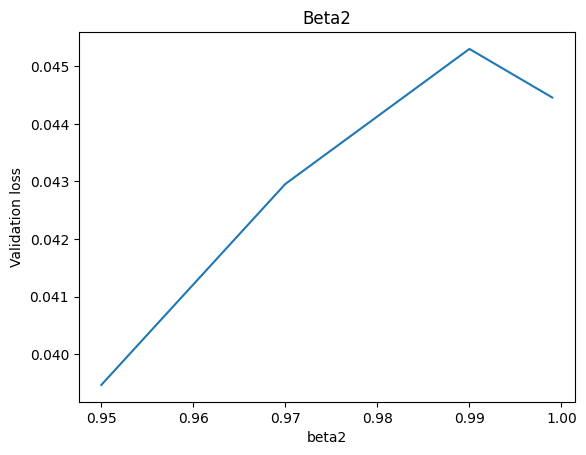

In [119]:
plt.plot(sweep_df["beta2"], sweep_df["val_loss"])
plt.xlabel("beta2")
plt.ylabel("Validation loss")
plt.title("Beta2")

In [120]:
# Sweep weight decay
sweep_df = df[(df["beta2"] == 0.999) & (df["n_warmup_steps"] == 0.0)]
sweep_df = pd.concat([sweep_df, baseline], ignore_index=True).sort_values(by="weight_decay", ascending=True)

In [121]:
sweep_df

,batch_size,n_steps,beta1,beta2,weight_decay,n_warmup_steps,lr_exponent,train_loss,val_loss,step_time
3,64,256,0.9,0.999,0.00,0.0,-16.0,0.042481,0.044457,25.512008
0,64,256,0.9,0.999,0.01,0.0,-16.0,0.044015,0.046083,26.047385
1,64,256,0.9,0.999,0.05,0.0,-16.0,0.042821,0.044853,25.262789
2,64,256,0.9,0.999,0.10,0.0,-16.0,0.045687,0.047682,25.373743


Text(0.5, 1.0, 'Weight decay')

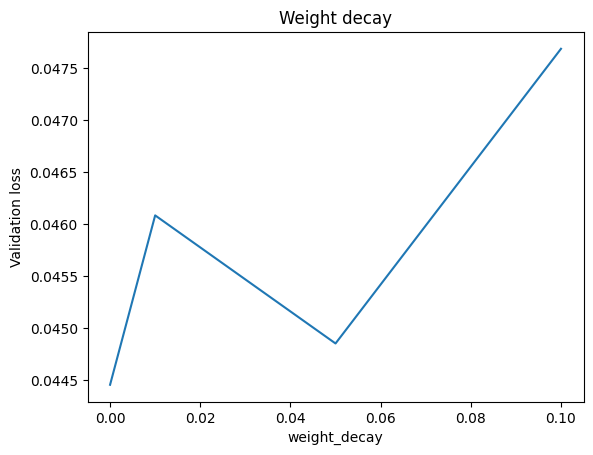

In [122]:
plt.plot(sweep_df["weight_decay"], sweep_df["val_loss"])
plt.xlabel("weight_decay")
plt.ylabel("Validation loss")
plt.title("Weight decay")

In [123]:
# Sweep warmup
sweep_df = df[(df["beta2"] == 0.999) & (df["weight_decay"] == 0.0)]
sweep_df = pd.concat([sweep_df, baseline], ignore_index=True).sort_values(by="n_warmup_steps", ascending=True)


In [124]:
sweep_df

,batch_size,n_steps,beta1,beta2,weight_decay,n_warmup_steps,lr_exponent,train_loss,val_loss,step_time
3,64,256,0.9,0.999,0.0,0.00,-16.0,0.042481,0.044457,25.512008
0,64,256,0.9,0.999,0.0,5.12,-16.0,0.044883,0.047242,25.169694
1,64,256,0.9,0.999,0.0,12.80,-16.0,0.048349,0.058389,25.355060
2,64,256,0.9,0.999,0.0,25.60,-16.0,0.044298,0.046469,25.254489


Text(0.5, 1.0, 'Warmup')

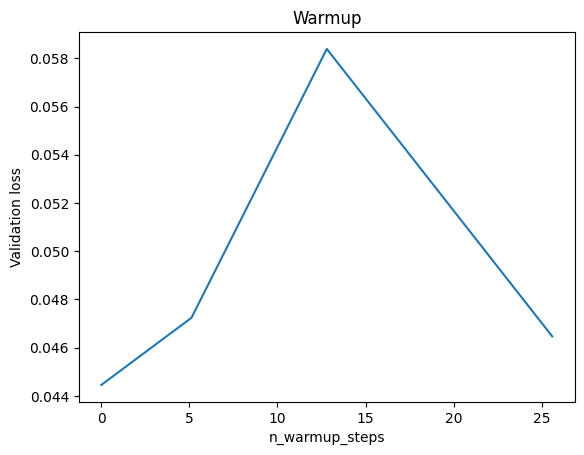

In [125]:
plt.plot(sweep_df["n_warmup_steps"], sweep_df["val_loss"])
plt.xlabel("n_warmup_steps")
plt.ylabel("Validation loss")
plt.title("Warmup")